In [23]:
import numpy as np
import pandas as pd
from pathlib import Path

In [24]:
df =pd.read_csv("New/end-to-end-ml/content/placement.csv")

In [25]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [26]:
df.shape

(100, 4)

## Steps

### 0. Preprocess + EDA + Feature Selection
### 1. Extract input and output cols
### 2. Scale the values
### 3. Train test split
### 5. Evaluate the model/model selection
### 6. Deploy the model


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.2 KB


In [28]:
# Remove column Unnamed: 0
df=df.iloc[:,1:]

In [29]:
# EDA
import matplotlib.pyplot as plt

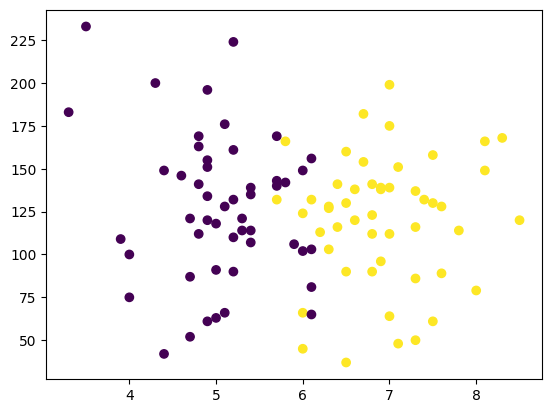

In [30]:
plt.scatter(df["cgpa"],df["iq"],c=df["placement"])

In [31]:
# Sepearaet (dependent and independent) or (input and output) features (columns)
X= df.iloc[:,0:2]
y= df.iloc[:,-1]

In [32]:
X.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [33]:
y.head()

0    1
1    0
2    0
3    1
4    0
Name: placement, dtype: int64

In [34]:
X.shape

(100, 2)

In [35]:
y.shape

(100,)

In [36]:
# Firstly we will do Train test split before Scale the values so that we can see Train test split before Scale the values.
from sklearn.model_selection import train_test_split

In [37]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [38]:
# Random 90 rows for input training data
X_train

,cgpa,iq
60,6.9,139.0
93,6.8,112.0
81,5.4,107.0
30,7.6,128.0
42,7.6,89.0
...,...,...
48,6.6,138.0
79,6.5,90.0
24,4.7,121.0
9,5.1,66.0


In [39]:
# Random 90 rows for output training data
y_train

60    1
93    1
81    0
30    1
42    1
     ..
48    1
79    1
24    0
9     0
27    1
Name: placement, Length: 90, dtype: int64

In [40]:
# Random 10 rows for input test data
X_test

,cgpa,iq
69,8.5,120.0
23,4.7,87.0
98,6.3,103.0
71,6.1,132.0
17,3.3,183.0
14,6.1,103.0
56,6.1,65.0
50,3.5,233.0
57,6.5,130.0
83,7.5,130.0


In [41]:
# Random 10 rows for output test data
y_test

69    1
23    0
98    1
71    1
17    0
14    0
56    0
50    0
57    1
83    1
Name: placement, dtype: int64

In [42]:
# Scale the values (Value range between -1 to 1)
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()

In [44]:
X_train = scaler.fit_transform(X_train)

In [45]:
X_train

array([[ 8.26571919e-01,  4.10055290e-01],
       [ 7.34160151e-01, -2.82875415e-01],
       [-5.59604591e-01, -4.11195916e-01],
       [ 1.47345429e+00,  1.27750188e-01],
       [ 1.47345429e+00, -8.73149720e-01],
       [-5.59604591e-01,  4.10055290e-01],
       [ 1.38104252e+00,  8.97673193e-01],
       [-1.94578110e+00, -3.59867716e-01],
       [ 6.41748384e-01,  1.51361160e+00],
       [-1.20648696e+00, -1.82272143e+00],
       [-7.44428126e-01,  9.74665494e-01],
       [ 2.72101315e-01,  1.02086087e-01],
       [-1.02166343e+00, -1.59174452e+00],
       [-5.59604591e-01, -2.31547215e-01],
       [ 1.93551313e+00,  6.66696292e-01],
       [-9.29251660e-01, -8.21821519e-01],
       [-7.44428126e-01, -8.47485620e-01],
       [-1.11407519e+00,  4.61383490e-01],
       [-2.82369289e-01,  2.30406588e-01],
       [ 9.18983686e-01,  1.33396290e+00],
       [ 1.19621899e+00, -1.87404963e+00],
       [ 1.93551313e+00,  1.10298599e+00],
       [-7.44428126e-01, -3.34203616e-01],
       [-1.

In [46]:
X_test = scaler.transform(X_test)

In [47]:
X_test

array([[ 2.3051602 , -0.07756261],
       [-1.20648696, -0.92447792],
       [ 0.27210131, -0.51385232],
       [ 0.08727778,  0.23040659],
       [-2.5002517 ,  1.5392757 ],
       [ 0.08727778, -0.51385232],
       [ 0.08727778, -1.48908812],
       [-2.31542817,  2.82248071],
       [ 0.45692485,  0.17907839],
       [ 1.38104252,  0.17907839]])

In [48]:
# Train the model by using logistic regrestion (classifier)
from sklearn.linear_model import LogisticRegression

In [49]:
clf = LogisticRegression()

In [50]:
clf.fit(X_train,y_train)

LogisticRegression()

In [51]:
# Evaluate the model/model
y_pred = clf.predict(X_test)

In [52]:
y_test

69    1
23    0
98    1
71    1
17    0
14    0
56    0
50    0
57    1
83    1
Name: placement, dtype: int64

In [53]:
# Check the accuracy between y_pred and y_test
from sklearn.metrics import accuracy_score

In [54]:
accuracy_score(y_test,y_pred)


0.8

In [56]:
# Plote decision regions for visualize decision boundry created by logistic regression
from mlxtend.plotting import plot_decision_regions

<Axes: >

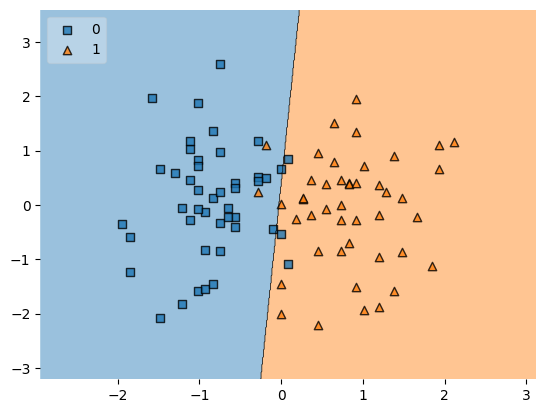

In [57]:
# Plotting decision regions
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [58]:
import pickle

In [60]:
pickle.dump(clf,open("New/end-to-end-ml/model.pkl","wb"))